已知：
输入特征 $X = \begin{bmatrix} 2.0 & -1.0 \end{bmatrix}$
标签 $y = 0$（类别0）
网络结构：
输入层：2个神经元
隐藏层：3个神经元，激活函数为 ReLU
输出层：2个神经元（对应二分类），无激活（CrossEntropyLoss自动加softmax）
参数初始化（均需 requires_grad=True）：
Apply to test45.ipynb
计算要求：
前向传播
计算隐藏层输出 $H = \text{ReLU}(X @ W1^T + b1)$
计算输出层 $Z = H @ W2^T + b2$
用 nn.CrossEntropyLoss() 计算损失
反向传播
调用 loss.backward()，获得各参数的梯度
参数更新
用学习率 lr=0.05，手动SGD更新一次参数（不使用优化器）
输出结果
打印 softmax 后的输出概率
打印损失值
打印每个参数的梯度
打印更新后的参数值

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")

In [ ]:
#前向传播
def forward(w1, w2, b1, b2, x):
  z1 = x @ w1.T + b1
  h = torch.relu(z1)

  z2 = h @ w2.T + b2
  return z2

epoch: 1 loss: 0.6685
epoch: 11 loss: 0.3809
epoch: 21 loss: 0.1917
epoch: 31 loss: 0.1010
epoch: 41 loss: 0.0605
epoch: 51 loss: 0.0405
epoch: 61 loss: 0.0294
epoch: 71 loss: 0.0226
epoch: 81 loss: 0.0180
epoch: 91 loss: 0.0149
epoch: 101 loss: 0.0126
epoch: 111 loss: 0.0108
epoch: 121 loss: 0.0094
epoch: 131 loss: 0.0083
epoch: 141 loss: 0.0075
epoch: 151 loss: 0.0067
epoch: 161 loss: 0.0061
epoch: 171 loss: 0.0056
epoch: 181 loss: 0.0052
epoch: 191 loss: 0.0048
the predication value is:
tensor([[0.9891, 0.0109]], grad_fn=<SoftmaxBackward0>)
the y_pred index value is:
tensor(0)
the y_true index value is:
tensor([0])


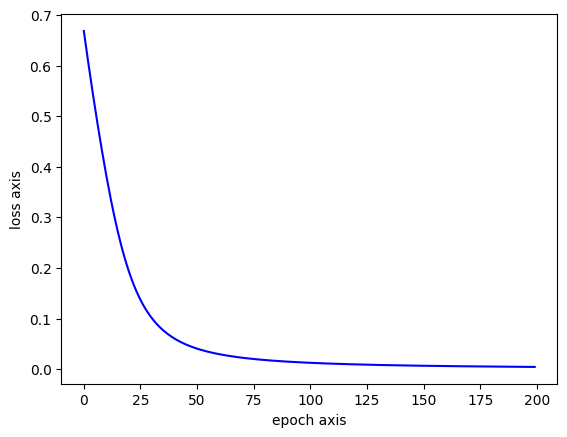

In [ ]:
#初始化参数
w1 = torch.tensor([[0.2, -0.1],
          [0.1,  0.3],
          [-0.2, 0.2]], requires_grad=True)   # shape = [3, 2]

b1 = torch.tensor([0.0, 0.1, -0.1], requires_grad=True)  # shape = [3]

w2 = torch.tensor([[0.1, -0.2, 0.2],
          [-0.1, 0.1, 0.1]], requires_grad=True)  # shape = [2, 3]

b2 = torch.tensor([0.0, 0.05], requires_grad=True)         # shape = [2]

x = torch.tensor([[2.0, -1.0]]) # shape [1,2]
y_true_index = torch.tensor([0])

losses = []
epochs = 200
lr = 0.05

criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
  z2 = forward(w1, w2, b1, b2, x)

  loss = criterion(z2, y_true_index)
  losses.append(loss.item())

  loss.backward()

  with torch.no_grad():
    w1 -= lr * w1.grad
    w2 -= lr * w2.grad
    b1 -= lr * b1.grad
    b2 -= lr * b2.grad

  w1.grad.zero_()
  w2.grad.zero_()
  b1.grad.zero_()
  b2.grad.zero_()

  if epoch % 10 == 0:
    print(f"epoch: {epoch+1}",
      f"loss: {loss.item():.4f}")

with torch.no_grad():
  y_pred_index = torch.argmax(y_pred)

print("the predication value is:")
print(y_pred)

print("the y_pred index value is:")
print(y_pred_index)

print("the y_true index value is:")
print(y_true_index)

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")

plt.show()